# Lab 8

## 1. Data Preprocessing

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hammaadali/insects-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insects-recognition' dataset.
Path to dataset files: /kaggle/input/insects-recognition


In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Set parameters
img_size = (128, 128)
data_dir = path # Corrected path: assuming 'path' directly points to the image root directory

# Prepare lists for images and labels
images = []
labels = []

# Load images and labels
for label in os.listdir(data_dir):
  label_dir = os.path.join(data_dir, label)
  if os.path.isdir(label_dir):
    for img_file in os.listdir(label_dir):
      img_path = os.path.join(label_dir, img_file)
      try:
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img) / 255.0  # normalize
        images.append(img_array)
        labels.append(label)
      except Exception as e:
        continue  # skip unreadable files

images = np.array(images)
labels = np.array(labels)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
  images, labels, test_size=0.2, random_state=42, stratify=labels
)

## 2. Model Development

In [7]:
from tensorflow.keras import layers, models

# Encoder
encoder_input = layers.Input(shape=img_size + (3,))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder (symmetric)
x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = models.Model(encoder_input, decoder_output)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training Phase

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - loss: 0.0726 - val_loss: 0.0212
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0184 - val_loss: 0.0153
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0131 - val_loss: 0.0105
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0103 - val_loss: 0.0097
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0098 - val_loss: 0.0093
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0094 - val_loss: 0.0089
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0091 - val_loss: 0.0085
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0088 - val_loss: 0.0082
Epoch 9/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0085 - val_loss: 0.0081
Epoch 10/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0080 - val_loss: 0.0085
Epoch 11/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0080 - val_loss: 0.0076
Epoch 12/20
112/112 ━━━━━━━━━━━━━━━━━━━

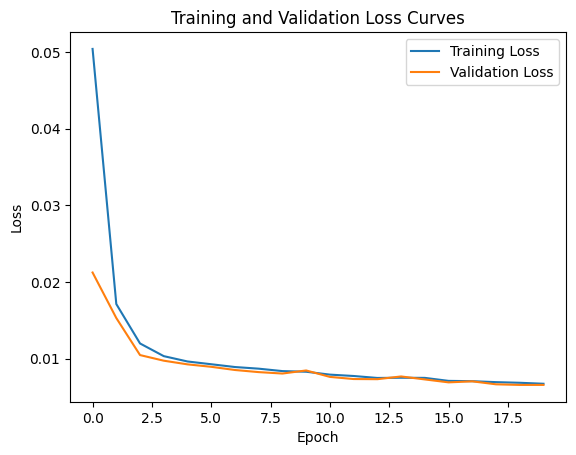

In [ ]:
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
  X_train, X_train,
  epochs=20,
  batch_size=32,
  validation_data=(X_test, X_test)
)

autoencoder.save('insect_autoencoder.keras')

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

## 4. Evaluation & Output

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


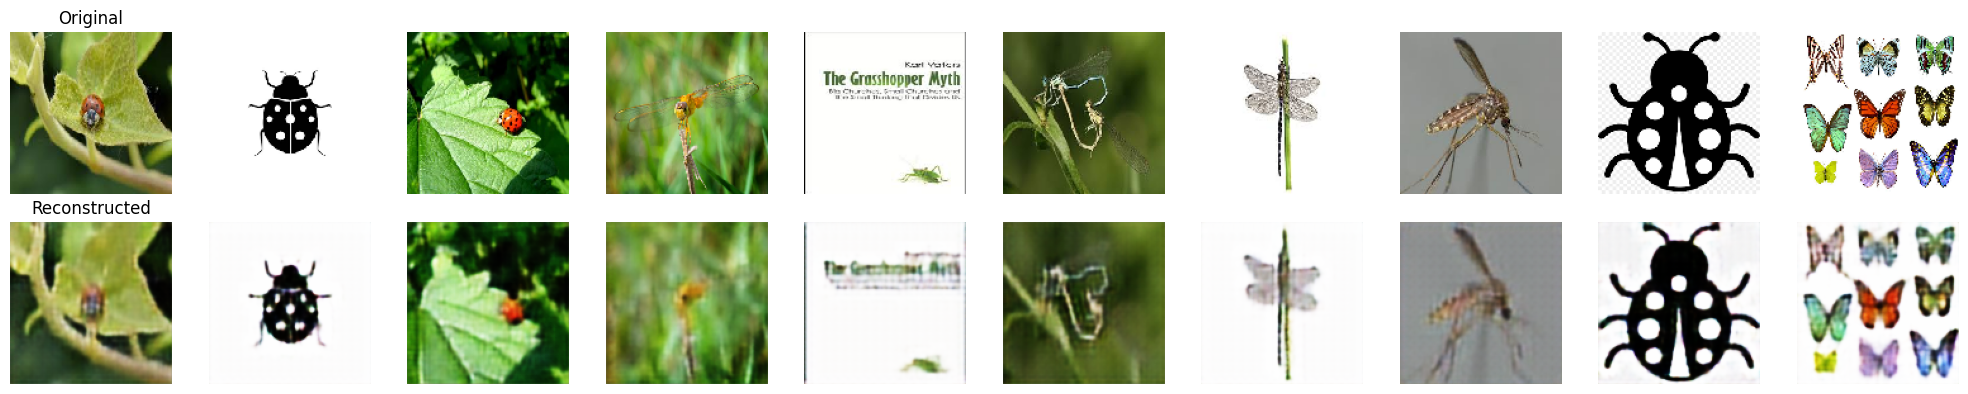

In [9]:
# Select a sample of test images
num_samples = 10
sample_images = X_test[:num_samples]

# Reconstruct images using the autoencoder
reconstructed_images = autoencoder.predict(sample_images)

# Plot original and reconstructed images side by side
fig, axes = plt.subplots(2, num_samples, figsize=(20, 4))
for i in range(num_samples):
  # Original
  axes[0, i].imshow(sample_images[i])
  axes[0, i].axis('off')
  if i == 0:
    axes[0, i].set_title('Original')
  # Reconstructed
  axes[1, i].imshow(reconstructed_images[i])
  axes[1, i].axis('off')
  if i == 0:
    axes[1, i].set_title('Reconstructed')
plt.tight_layout()
plt.show()

### 5. Discussion

- **Reconstruction Quality:**  
  The reconstructed images visually resemble the original inputs, indicating that the autoencoder has learned to capture the main features of the insect images. However, some fine details and textures may be lost, resulting in slightly blurred reconstructions.

- **Feature Compression:**  
  The encoder compresses the input images into a lower-dimensional representation, effectively extracting essential features while discarding redundant information. This compression enables efficient storage and can be useful for downstream tasks such as clustering or anomaly detection.

- **Errors:**  
  Reconstruction errors are visible as differences between the original and reconstructed images, especially in regions with complex patterns or rare features. These errors may be due to model capacity, insufficient training, or inherent ambiguity in the data. The loss curves provide a quantitative measure of these errors, with lower values indicating better reconstruction.